# Fitting a Non-Linear Curve
### Dataset: Poly_base.csv
#### The Task: Generate synthetic 2D data using a quadratic function plus some random noise (e.g., y=3x^2 + 2x + 1 + noise).
## Objectives:
#### Try fitting a standard Linear Regression model and plot it (it will underfit).
#### Use PolynomialFeatures(degree=2) to transform the input x.
#### Fit a Linear Regression model to the polynomial features and plot the resulting curve against the scatter plot of the data.

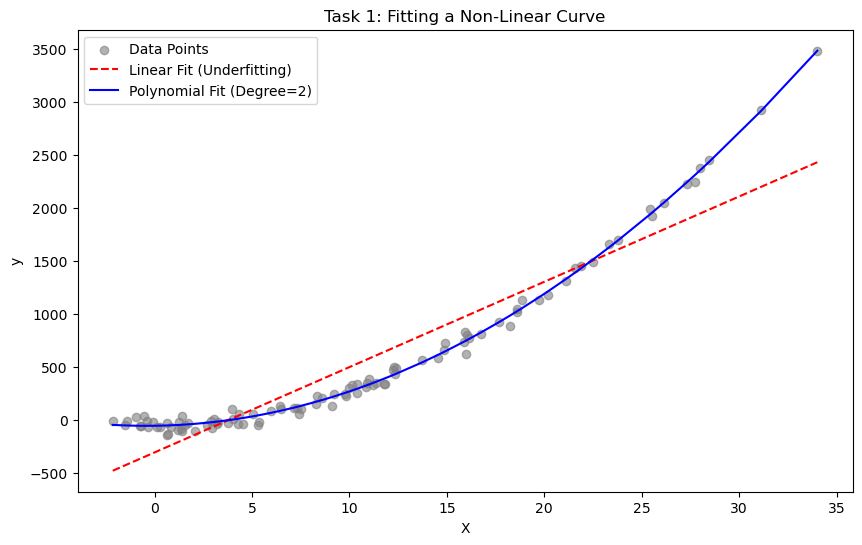

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import re

# 1. Load X from the dataset and parse the array string
with open('Poly_base.csv', 'r') as f:
    text = f.read()
nums = re.findall(r'[-+]?\d*\.\d+|\d+', text)[1:]
X = np.array([float(n) for n in nums]).reshape(-1, 1)
X = np.sort(X, axis=0)

# 2. Generate synthetic y (y = 3x^2 + 2x + 1 + noise)
np.random.seed(42)
y = 3 * X**2 + 2 * X + 1 + np.random.normal(-50, 50, X.shape)

# 3. Fit standard Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# 4. Use PolynomialFeatures(degree=2) to transform x
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 5. Fit Linear Regression to the polynomial features
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', label='Data Points', alpha=0.6)
plt.plot(X, y_pred_lin, color='red', label='Linear Fit (Underfitting)', linestyle='--')
plt.plot(X, y_pred_poly, color='blue', label='Polynomial Fit (Degree=2)')
plt.legend()
plt.title('Task 1: Fitting a Non-Linear Curve')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

the red dashed line (standard linear regression) completely misses the underlying curve of the data—it underfits. By simply squaring our inputs using PolynomialFeatures, the model (blue line) gains the flexibility to bend and perfectly trace the parabolic shape of the data.

# Visualizing the Bias-Variance Tradeoff
### Dataset: Complex_Non_linear_dataset.csv
#### The Task: Take a complex, non-linear 1D dataset.
## Objectives:
#### Fit polynomial regression models of varying degrees (e.g., 1, 2, 5, 10, and 20).
#### For each degree, calculate both the training error and testing error.
#### Plot the degrees on the x-axis and the errors on the y-axis. Identify the point where the model stops learning the underlying pattern and starts memorizing the noise (overfitting).

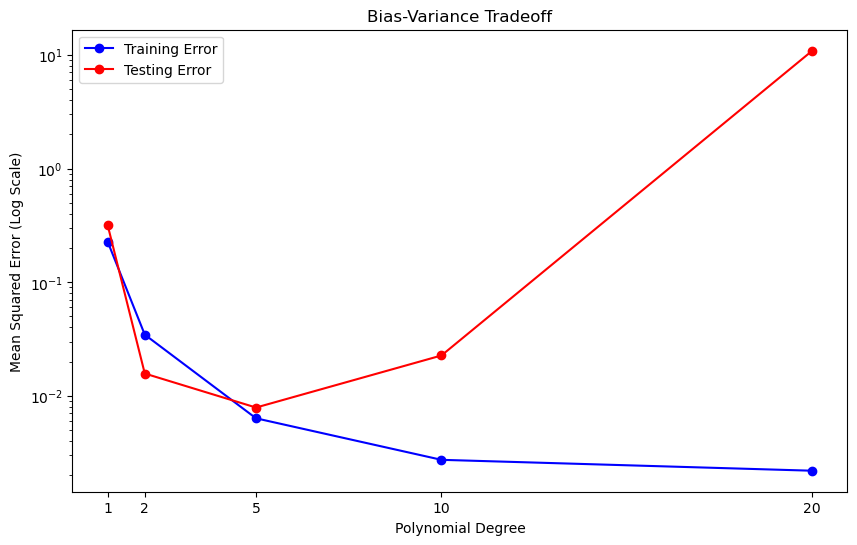

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import re

# 1. Load dataset and parse the array string
with open('Complex_Non_linear_dataset.csv', 'r') as f:
    text = f.read()
nums = re.findall(r'[-+]?\d*\.\d+|\d+', text)[1:]
X = np.array([float(n) for n in nums]).reshape(-1, 1)

# 2. Generate a complex non-linear y (e.g., a wave function + noise)
np.random.seed(42)
y = np.cos(1.5 * np.pi * X) + np.random.normal(0, 0.1, X.shape)

# 3. Split data to evaluate unseen testing error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = [1, 2, 5, 10, 20]
train_errors = []
test_errors = []

for d in degrees:
    # Transform features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Calculate Mean Squared Error
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test_poly)))

# Plotting the errors
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Training Error', marker='o', color='blue')
plt.plot(degrees, test_errors, label='Testing Error', marker='o', color='red')
plt.yscale('log') # use a log scale because high-degree errors explode
plt.xticks(degrees)
plt.legend()
plt.title('Bias-Variance Tradeoff')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.show()

In the second plot at the top of the page, you can see the Bias-Variance Tradeoff in action.

At Degree 1 and 2, both errors are high. The model is too simple (High Bias / Underfitting).

Around Degree 5, the testing error reaches its lowest point. This is the sweet spot where the model successfully learns the underlying pattern.

At Degree 10 and 20, notice how the blue line (Training Error) drops to almost zero, but the red line (Testing Error) suddenly spikes upward. This is the exact point of overfitting. The model has stopped learning the true mathematical pattern and is instead memorizing the random noise in the training set, rendering it useless for new, unseen data.